# Modular Dabest Visualisations

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
import random
import os
from scripts.visualisation import * # the visualisation module created, contains the functions to be used

plt.style.use('seaborn')


C:\Users\Aritejh\AppData\Local\Temp\ipykernel_2804\3632429562.py:10: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn')


## Setup Dataframes
we set up the LED df, as well as the random 3s before LED dataframe below. 

The metrics recorded are cumulative distance travelled, avg vel, avg acc, avg head-tail angle, minimum distance to LED (max height reached), % of frames above initial, magnitude of y travelled (from start to highest point), start to highest trajectory angle, 

The create_master_dataframe checks which columns are needed, and creates a master dataframe that is used downstream for visualisations. This is done so that we do not have to go back and create the dataframe for every new visualisation of the same experiment set data.

For creating new metrics, they have to be declared in create_master_dataframe and columns


In [2]:
# These are the data points created for analysis 
columns = ['name',
 'uroa_control',
 'day',
 'dist',
 'vel',
 'acc',
 'head_angle',
 'dist_surface',
 'y_up',
 'y_mag',
 'trajectory_angle',
 'start_y_from_led',
 'end_trajectory_angle']


In [3]:
# parameters with their meanings 
parameter_dict = {
    'dist': 'total distance travelled',
    'vel': 'average velocity',
    'acc': 'average acceleration',
    'head_angle': 'average tail-head angle',
    'dist_surface': 'distance from highest point in trajectory to LED',
    'y_up' : 'percentage of frames with y above starting y',
    'y_mag': 'magnitude of y between start and highest point',
    'trajectory_angle': 'angle between start and highest point',
    'start_y_from_led': 'distance from LED to start point',
    'end_trajectory_angle': 'angle between start and end point'
}


### modular plots

In [6]:
# creating a modular graph generator - Unpaired 
# 1. create dfs for each set of data
# you can create either LED or before LED dfs
EXPERIMENT_SET = 'd48_d77_LED'
df1_dlc_csv_path = Path("./data/output/d48_vr03_final")
df1_led_csv_path = Path("./data/output/d48_LED_times.csv")
df2_dlc_csv_path = Path("./data/output/d77_final")
df2_led_csv_path = Path("./data/output/d77_LED_times.csv")
# FOR LED: create_master_dataframe(columns, csv_files, led_csv, random_pre_led = False)
# FOR BEFORE LED: create_master_dataframe(columns, csv_files, led_csv, random_pre_led = True)

df1_csv_files = list(df1_dlc_csv_path.glob("**/*.csv"))
df1_led_csv = pd.read_csv(df1_led_csv_path)
df2_csv_files = list(df2_dlc_csv_path.glob("**/*.csv"))
df2_led_csv = pd.read_csv(df2_led_csv_path)

df1 = create_master_dataframe(columns, df1_csv_files, df1_led_csv, random_pre_led = False)
df2 = create_master_dataframe(columns, df2_csv_files, df2_led_csv, random_pre_led = False)


save_path = Path('./data/visualisation//dabest_modular/')
parameters = df1.columns[3:]



d48_24_M1.csv
d48_25_M1.csv
d48_27_M1.csv
d48_30_M1.csv
d48_32_M1.csv
d48_33_M1.csv
d48_34_M1.csv
d48_36_M1.csv
d48_38_M1.csv
d48_39_M1.csv
d48_40_M1.csv
d48_41_M1.csv
d48_45_M1.csv
d48_46_M1.csv
d48_50_M1.csv
d48_51_M1.csv
d48_54_M1.csv
d48_56_M1.csv
d48_57_M1.csv
d48_59_M1.csv
d48_60_M1.csv
d48_62_M1.csv
d48_63_M1.csv
d48_67_M1.csv
d48_68_M1.csv
d48_73_M1.csv
d48_74_M1.csv
d48_75_M1.csv
d48_78_M1.csv
d48_79_M1.csv
d48_81_M1.csv
d48_82_M1.csv
d48_84_M1.csv
d48_87_M1.csv
d48_24_T1.csv
d48_25_T1.csv
d48_27_T1.csv
d48_30_T3.csv
d48_32_T3.csv
d48_33_T1.csv
d48_34_T1.csv
d48_36_T1.csv
d48_38_T1.csv
d48_39_T1.csv
d48_40_T1.csv
d48_41_T1.csv
d48_45_T1.csv
d48_46_T1.csv
d48_50_T1.csv
d48_51_T1.csv
d48_54_T1.csv
d48_56_T1.csv
d48_57_T1.csv
d48_59_T1.csv
d48_60_T1.csv
d48_62_T1.csv
d48_63_T1.csv
d48_67_T1.csv
d48_68_T1.csv
d48_73_T1.csv
d48_74_T1.csv
d48_75_T1.csv
d48_78_Thu1.csv
d48_79_Thu1.csv
d48_81_Thu1.csv
d48_82_Thu1.csv
d48_84_Thu1.csv
d48_87_T1.csv
d48_24_F1.csv
d48_25_F1.csv
d48_27_F1.

In [5]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

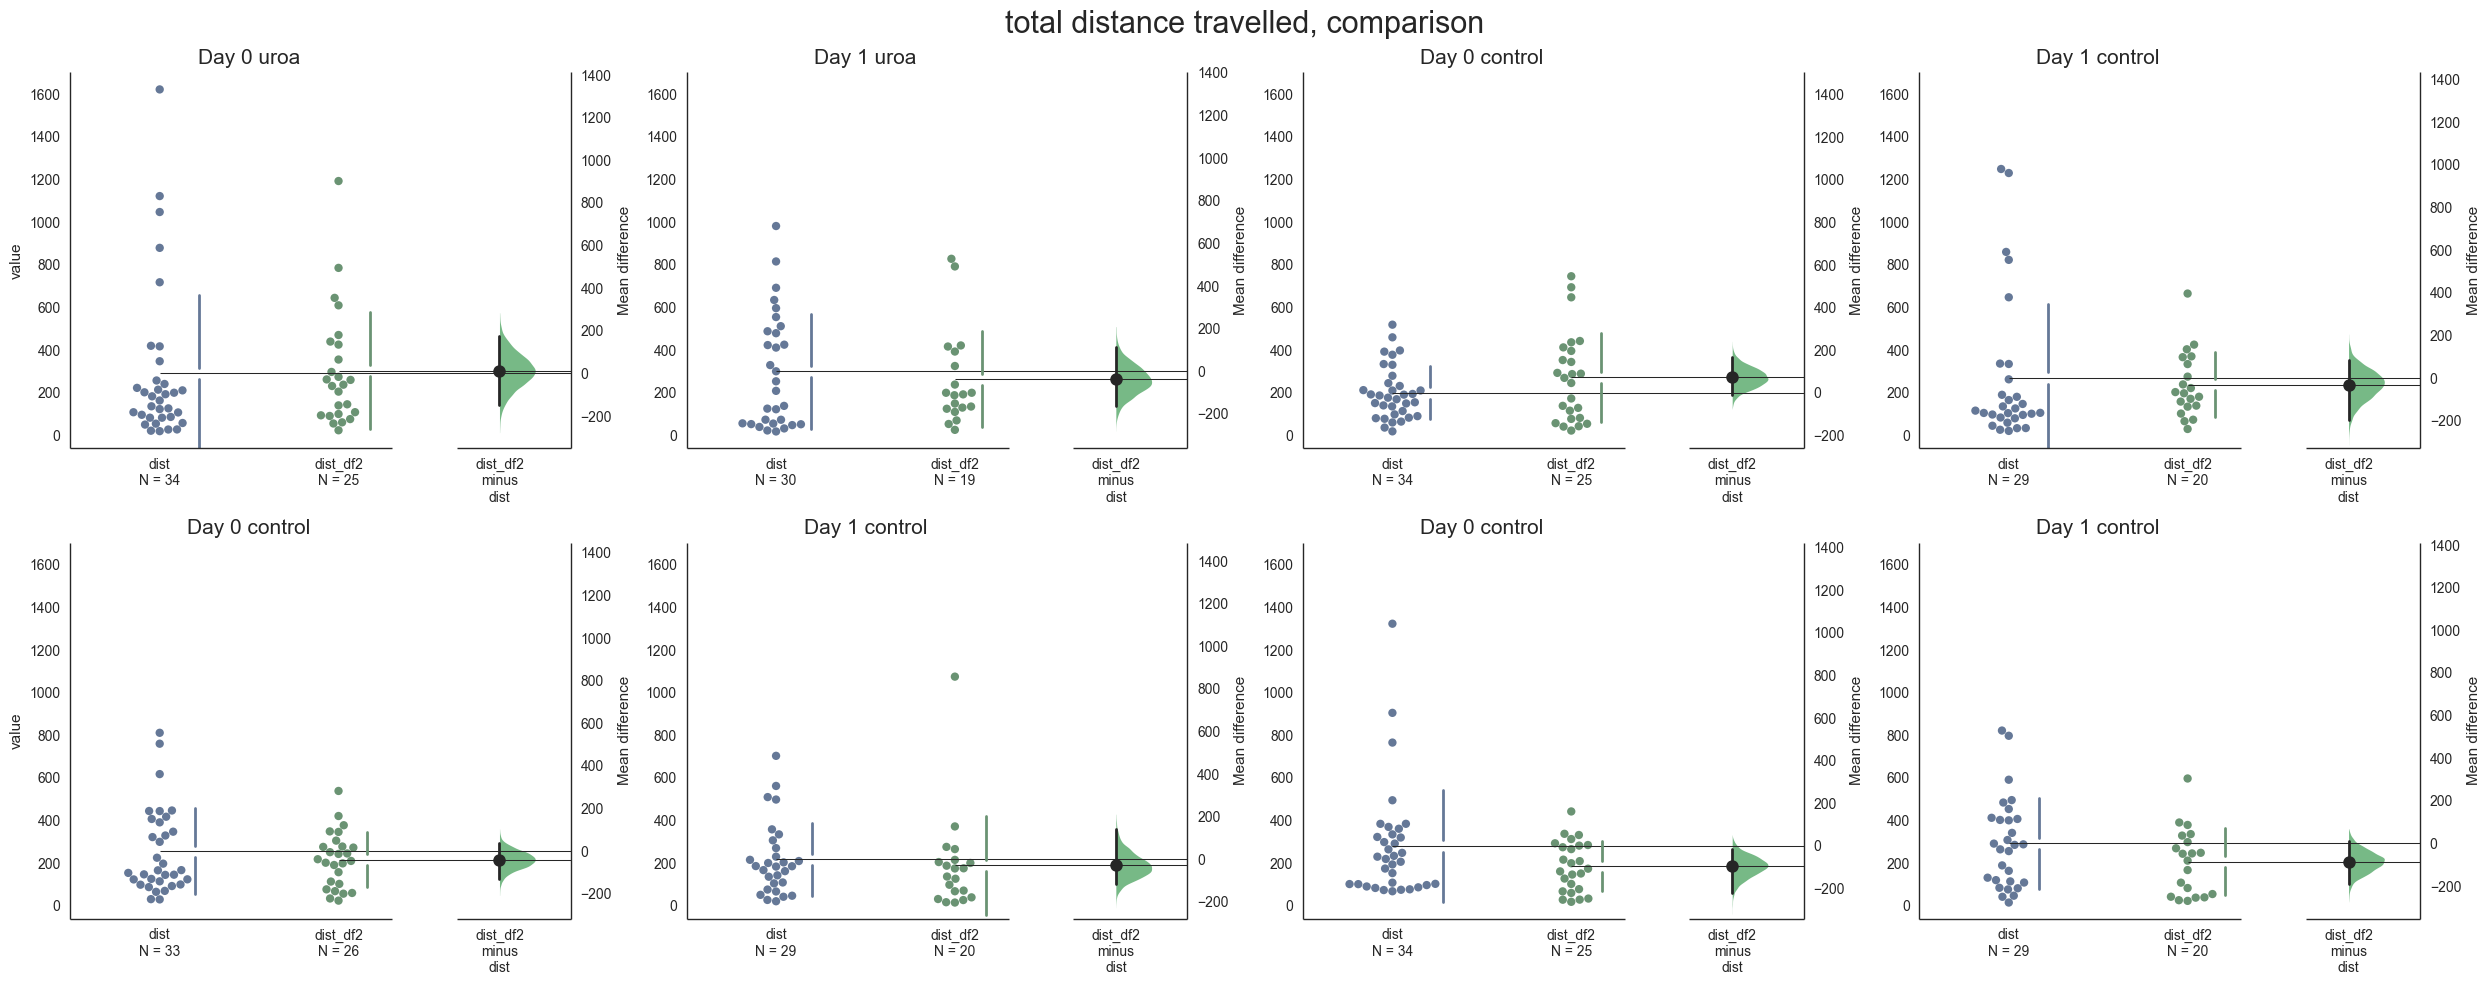

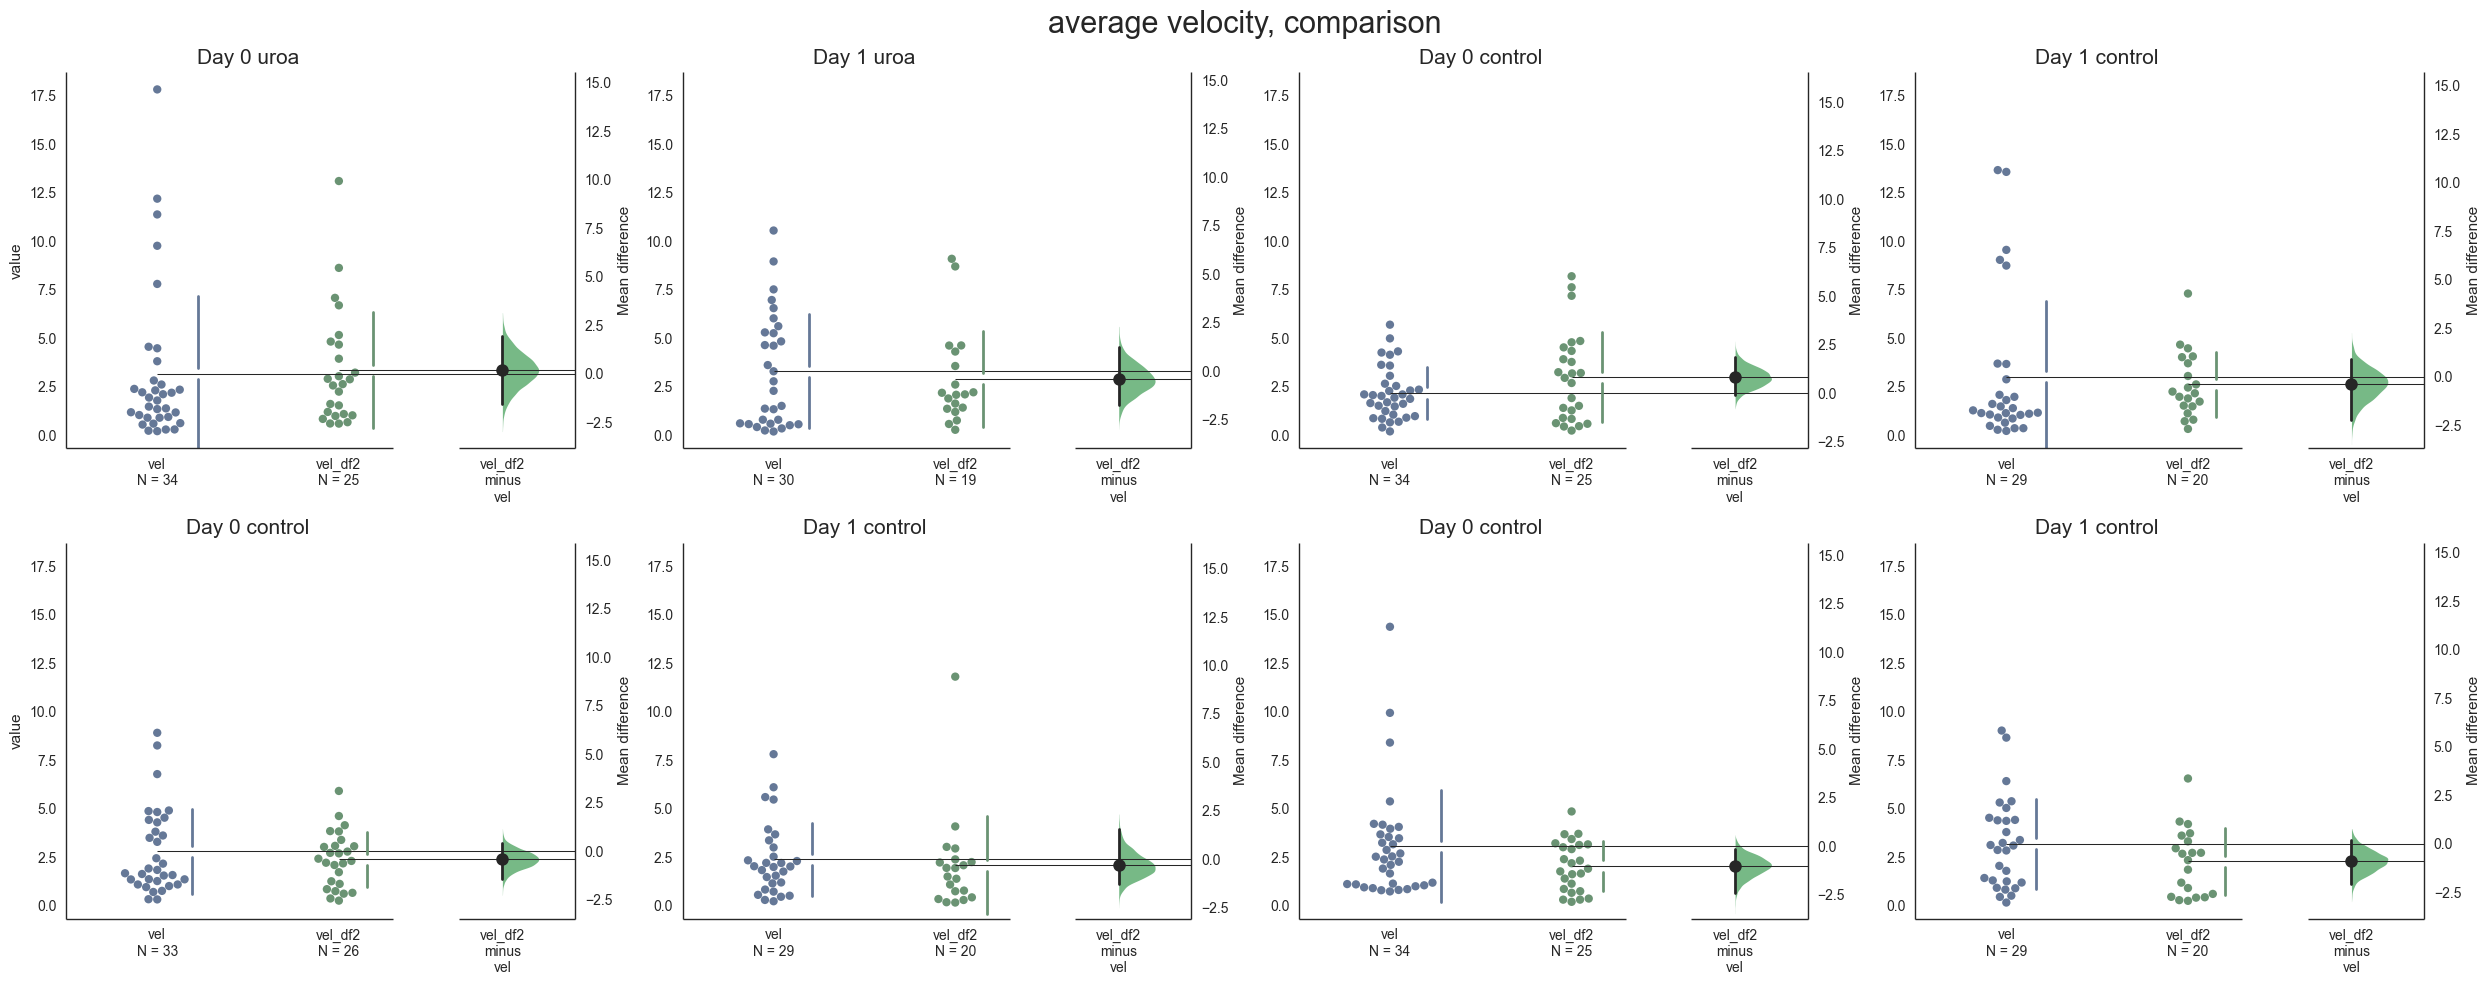

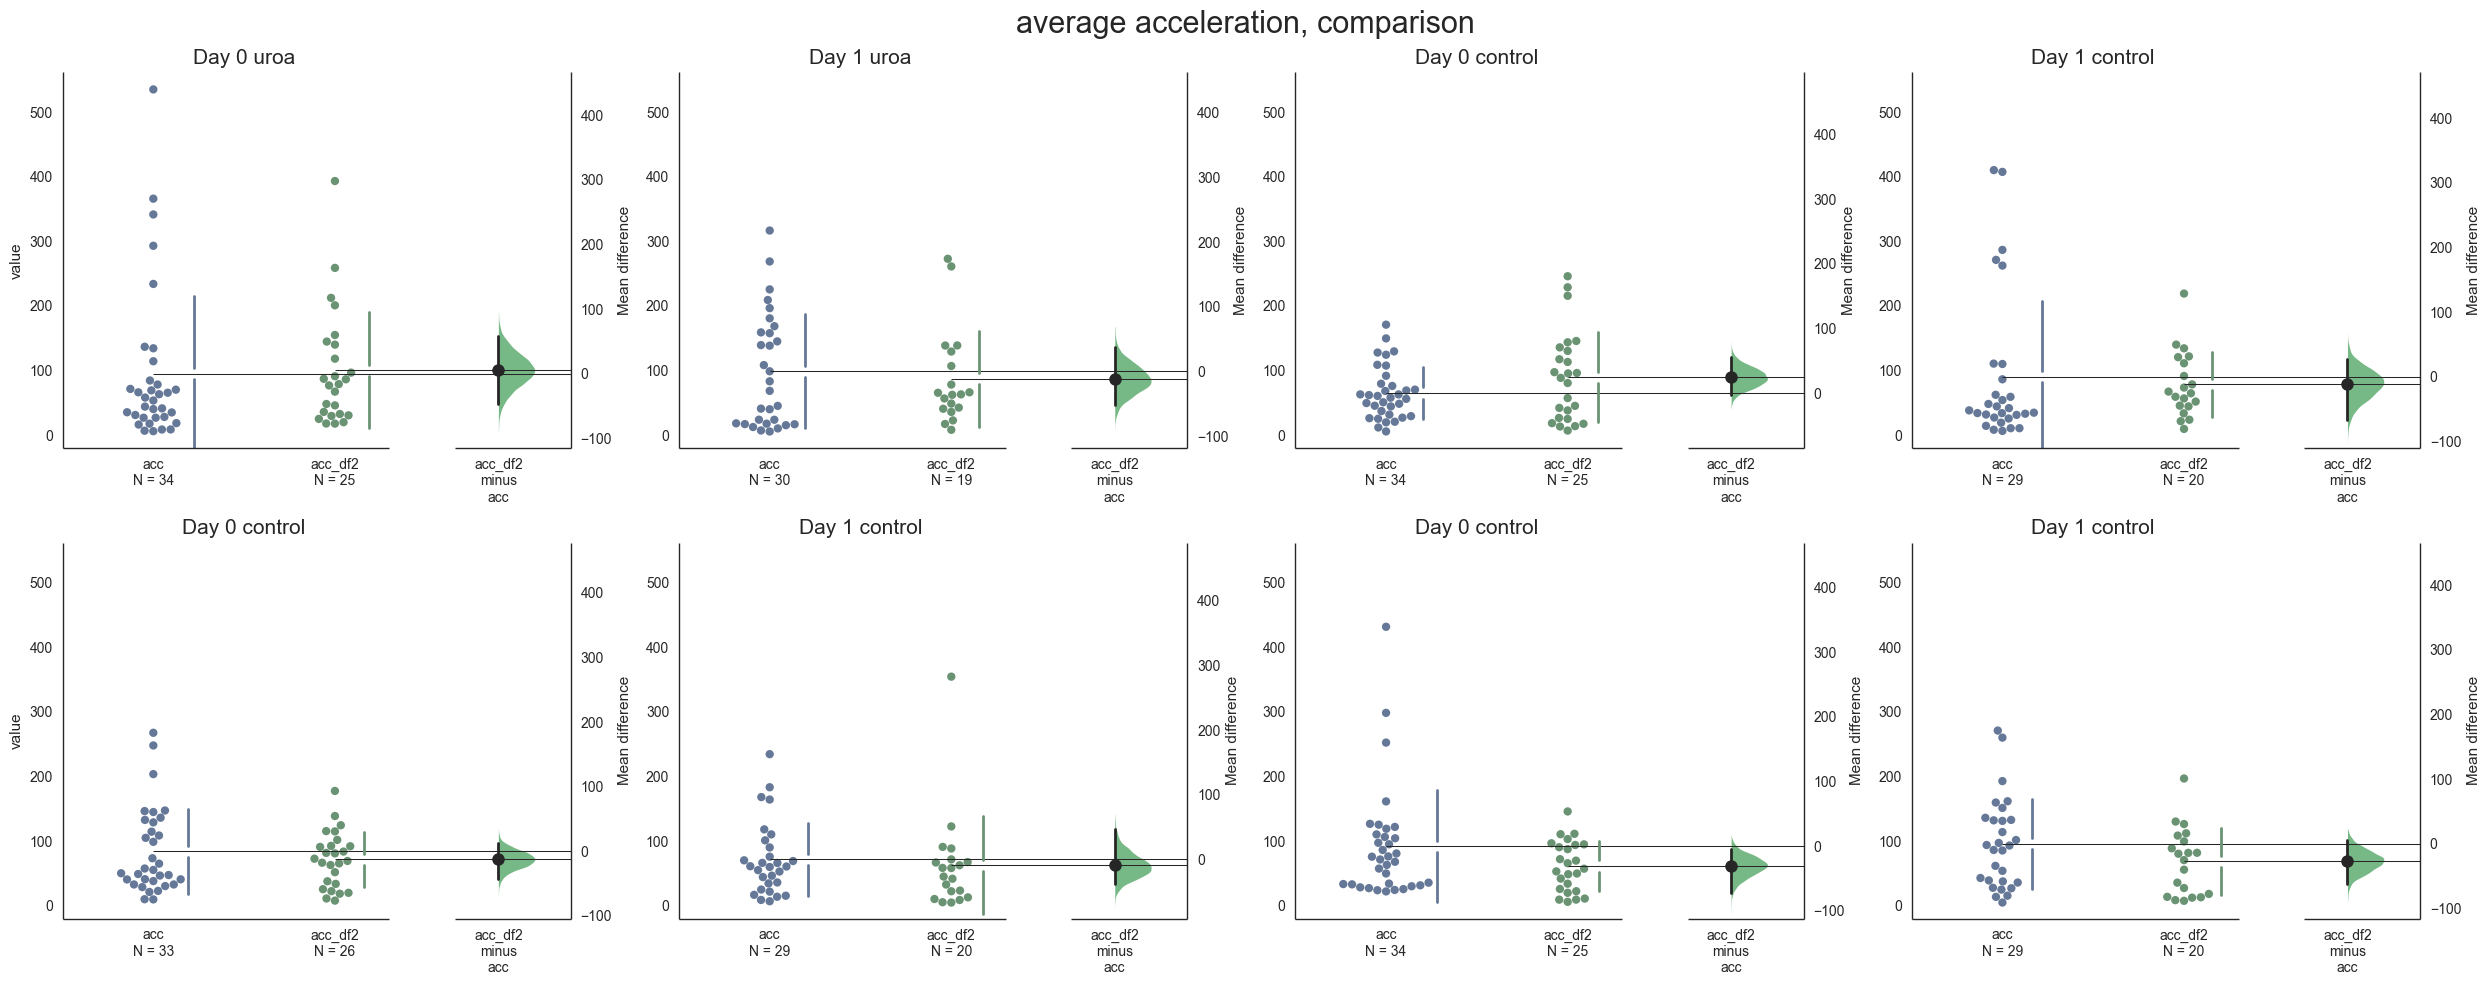

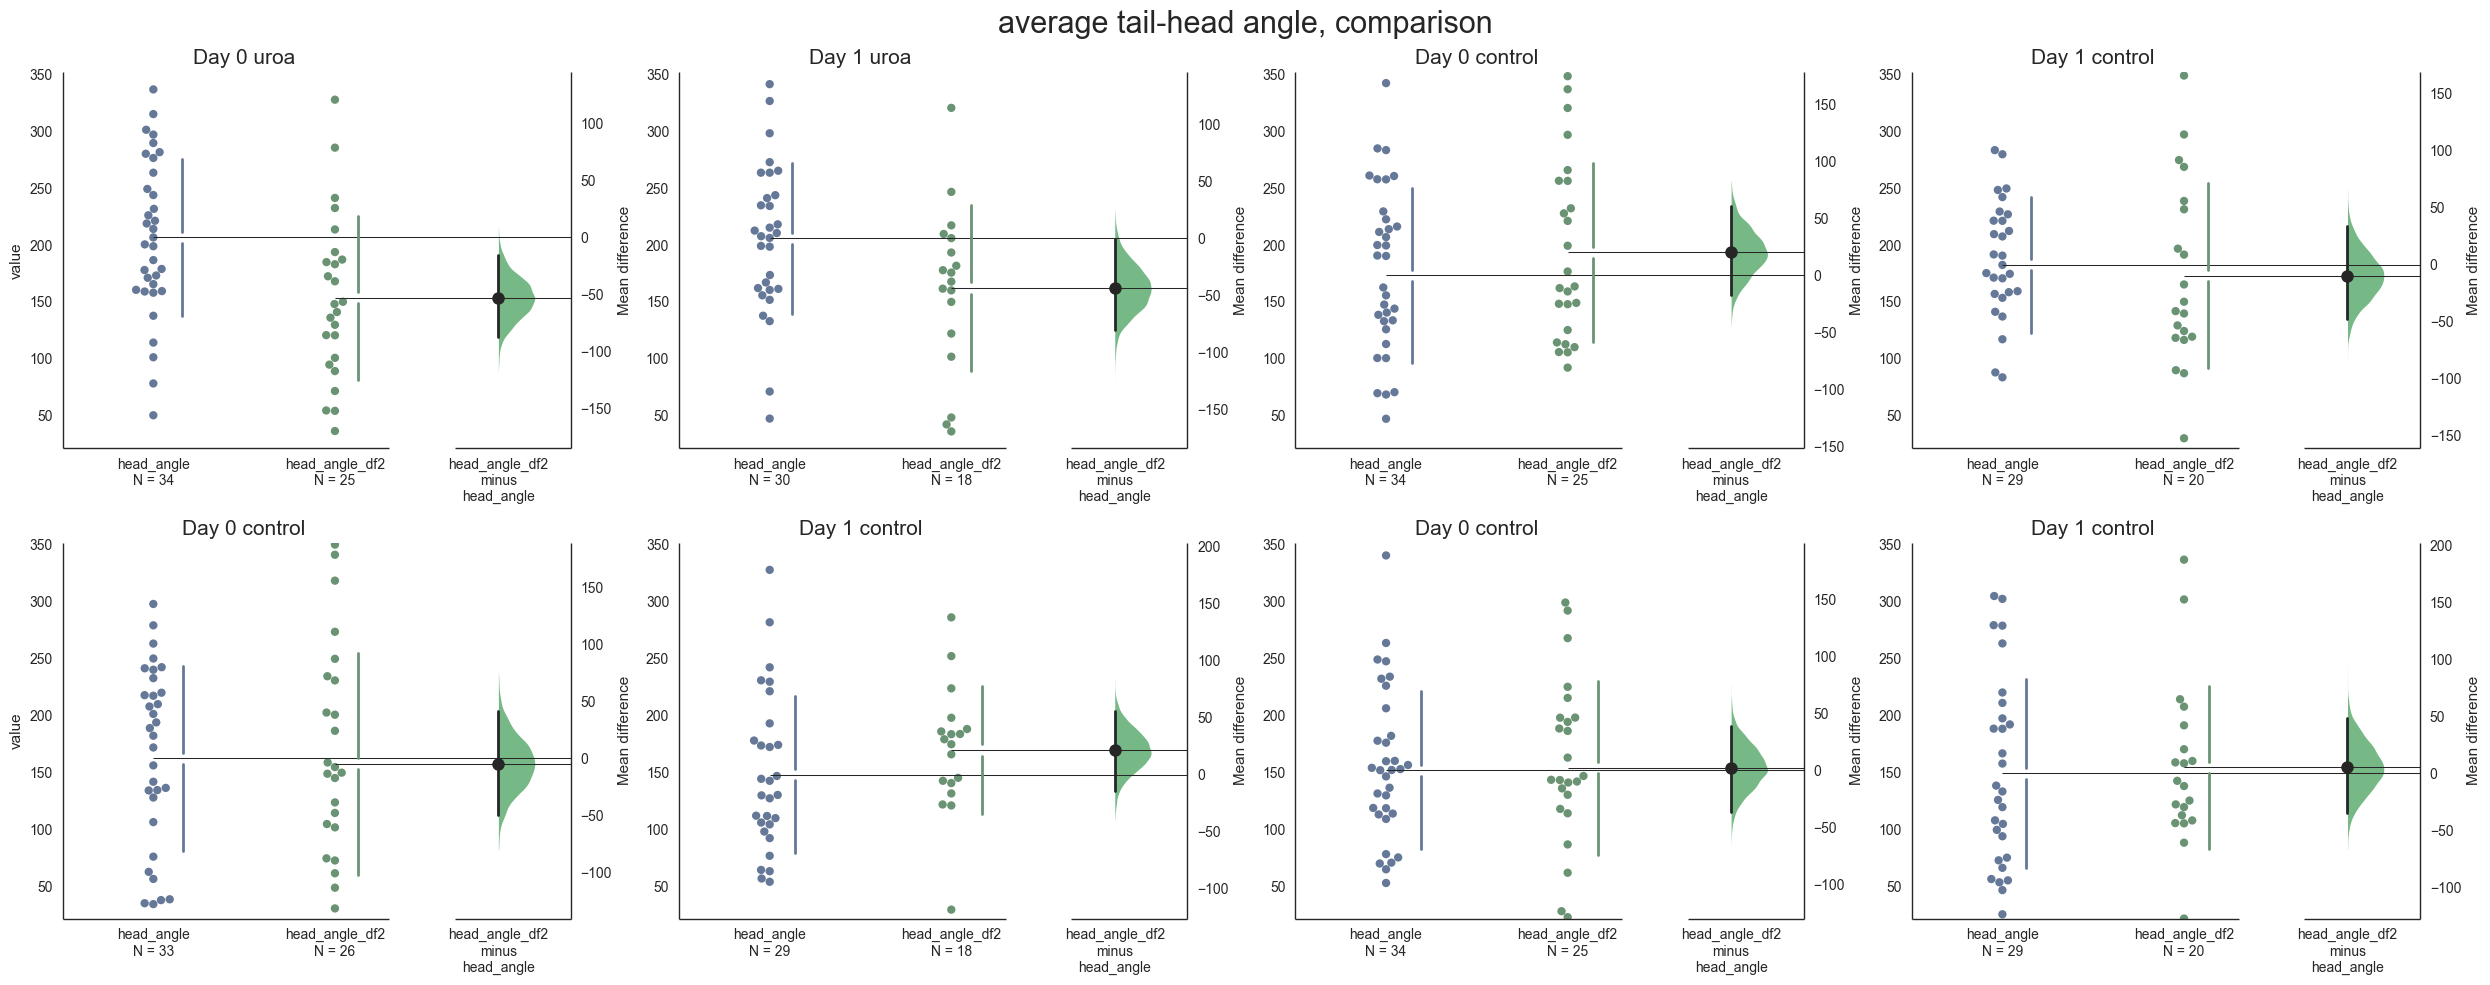

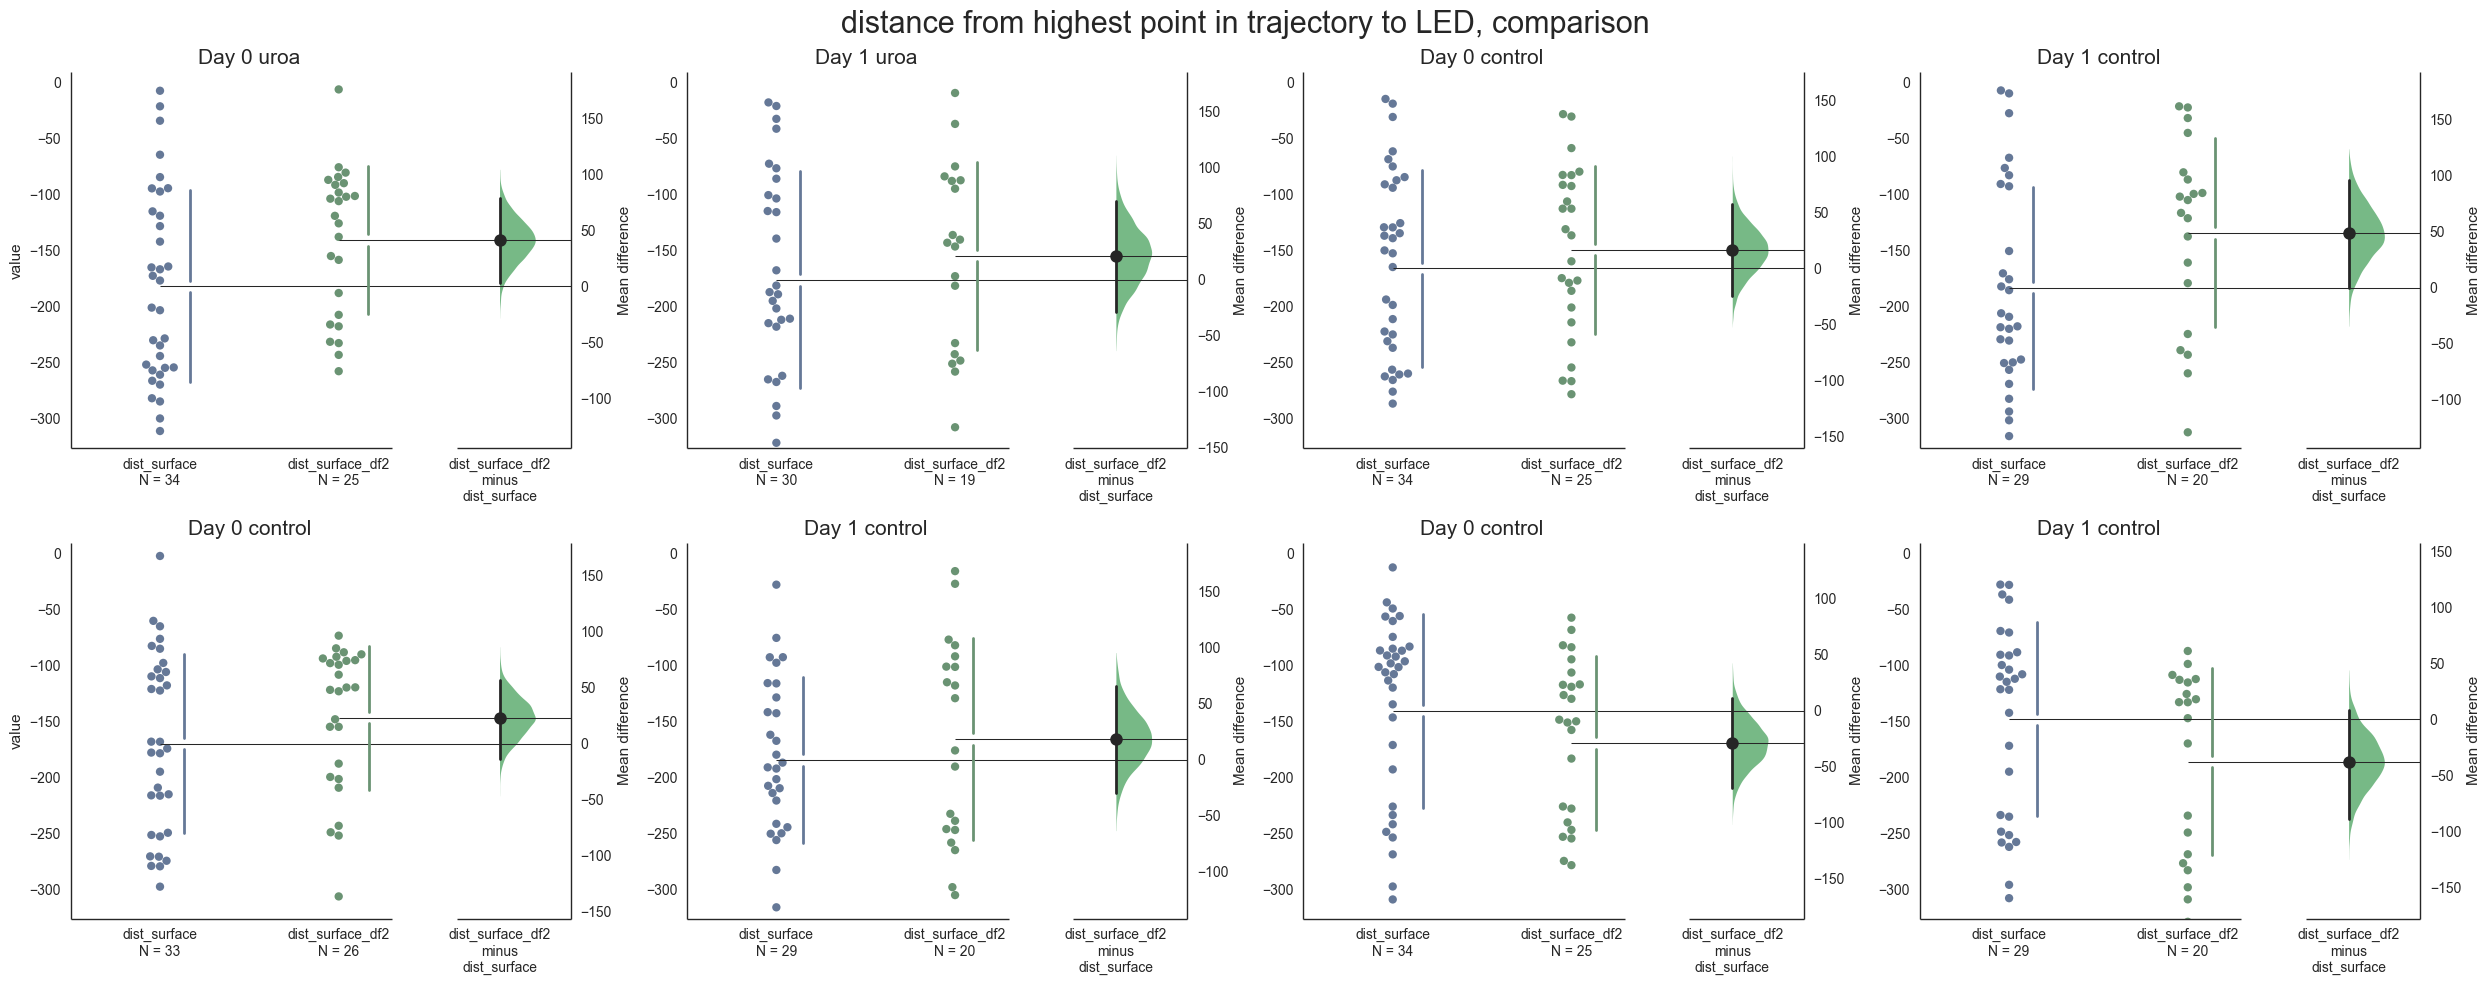

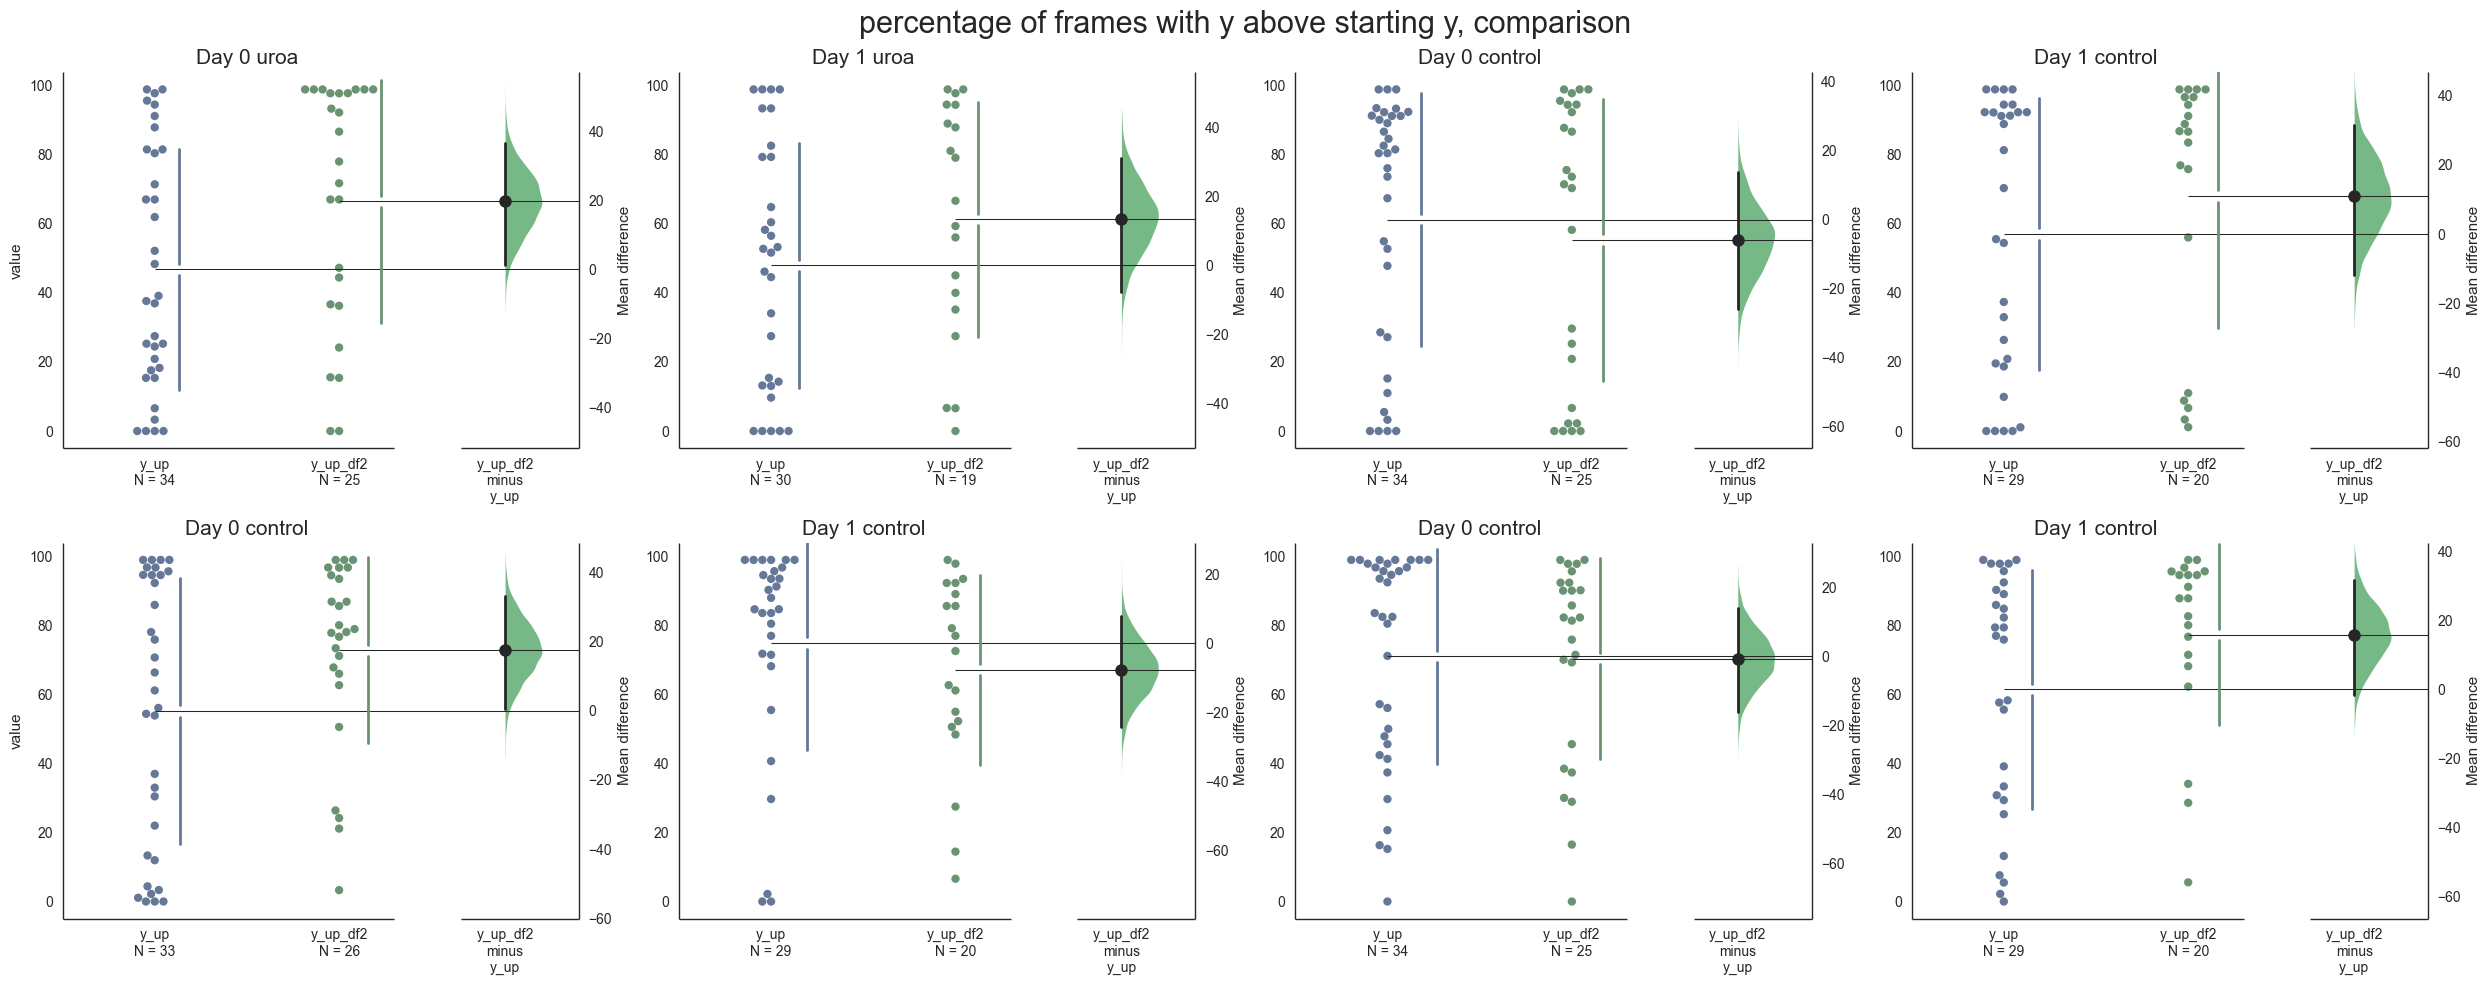

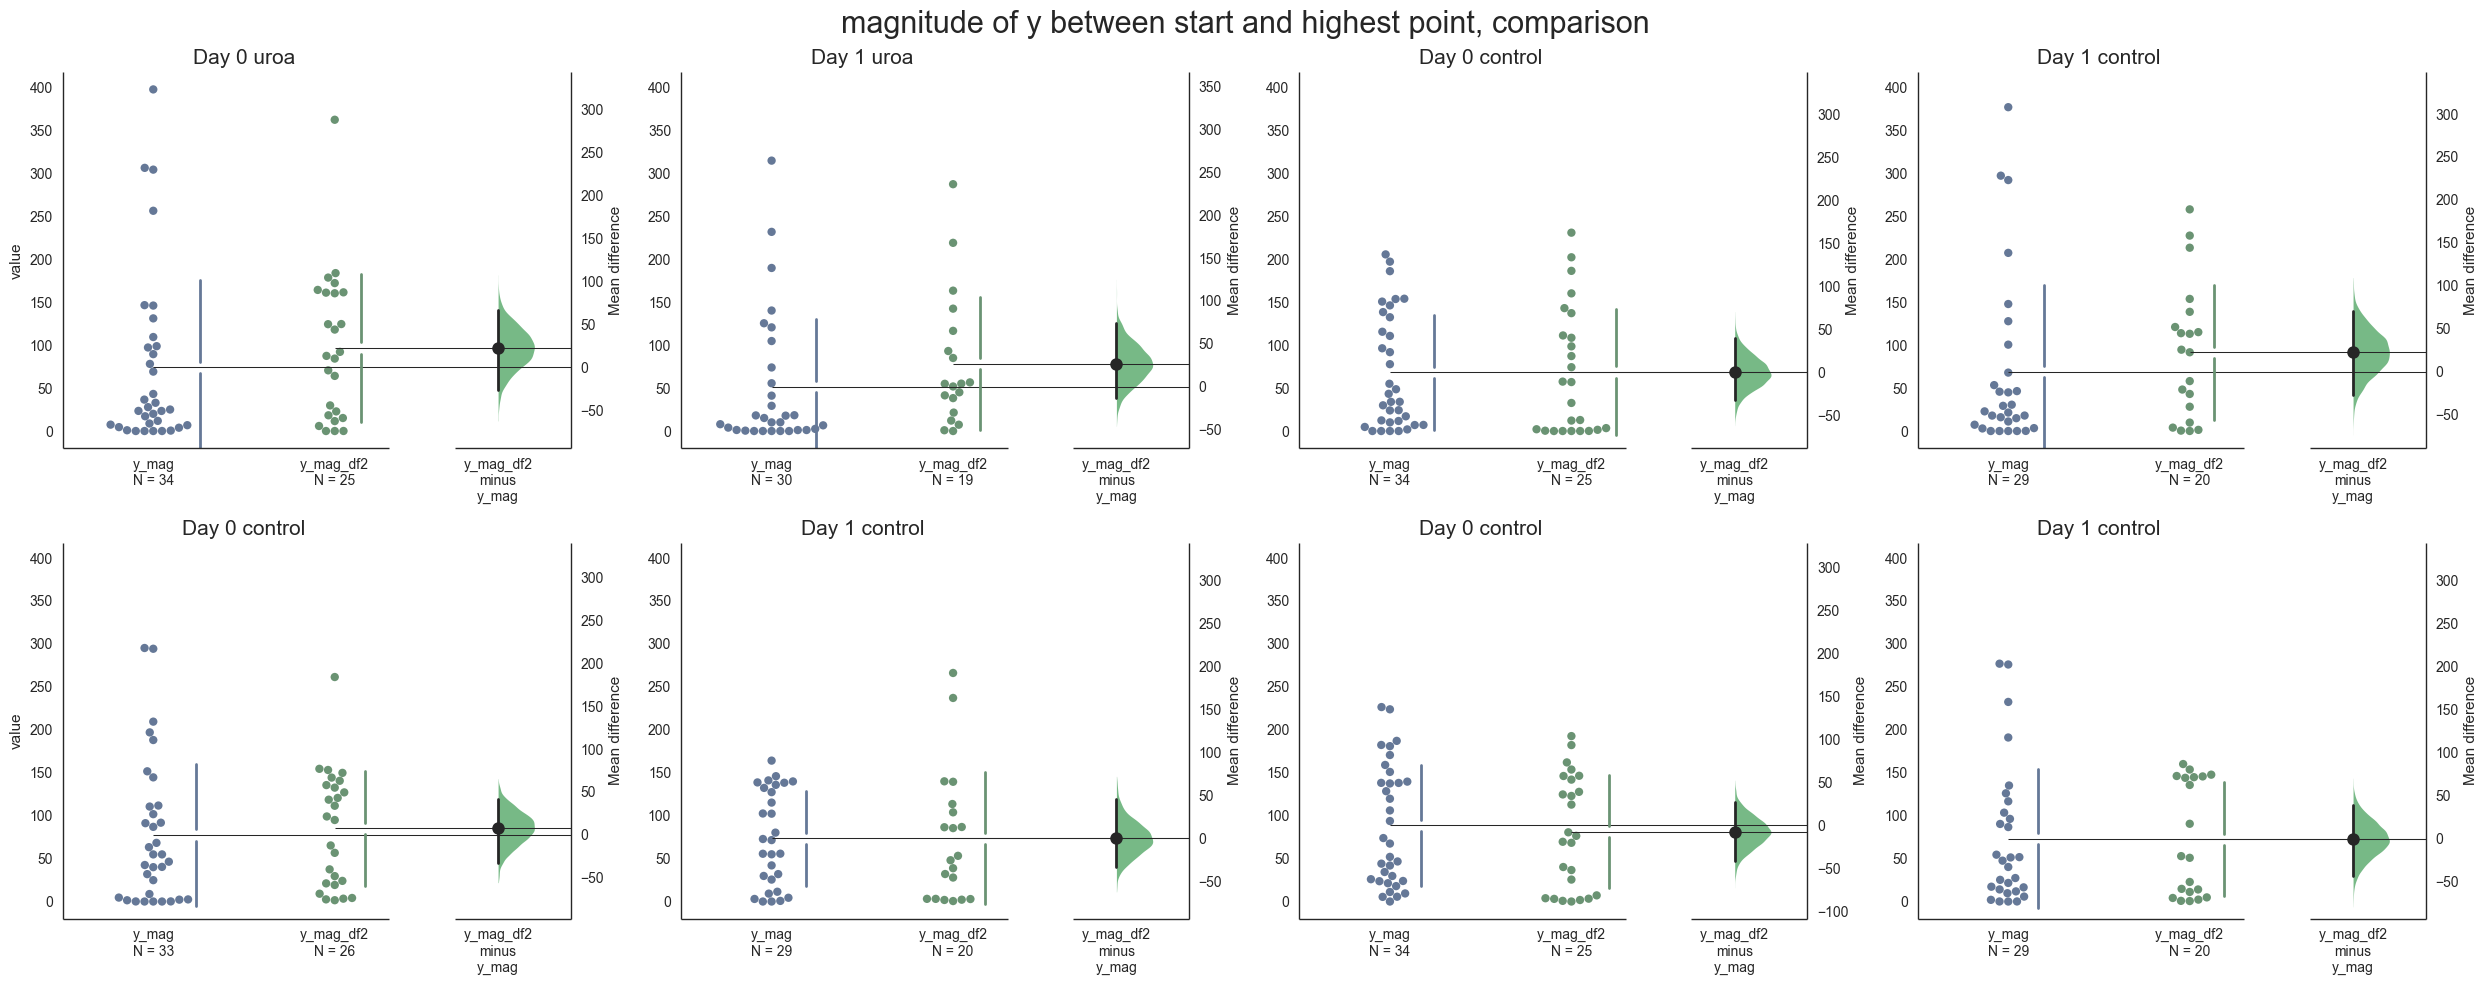

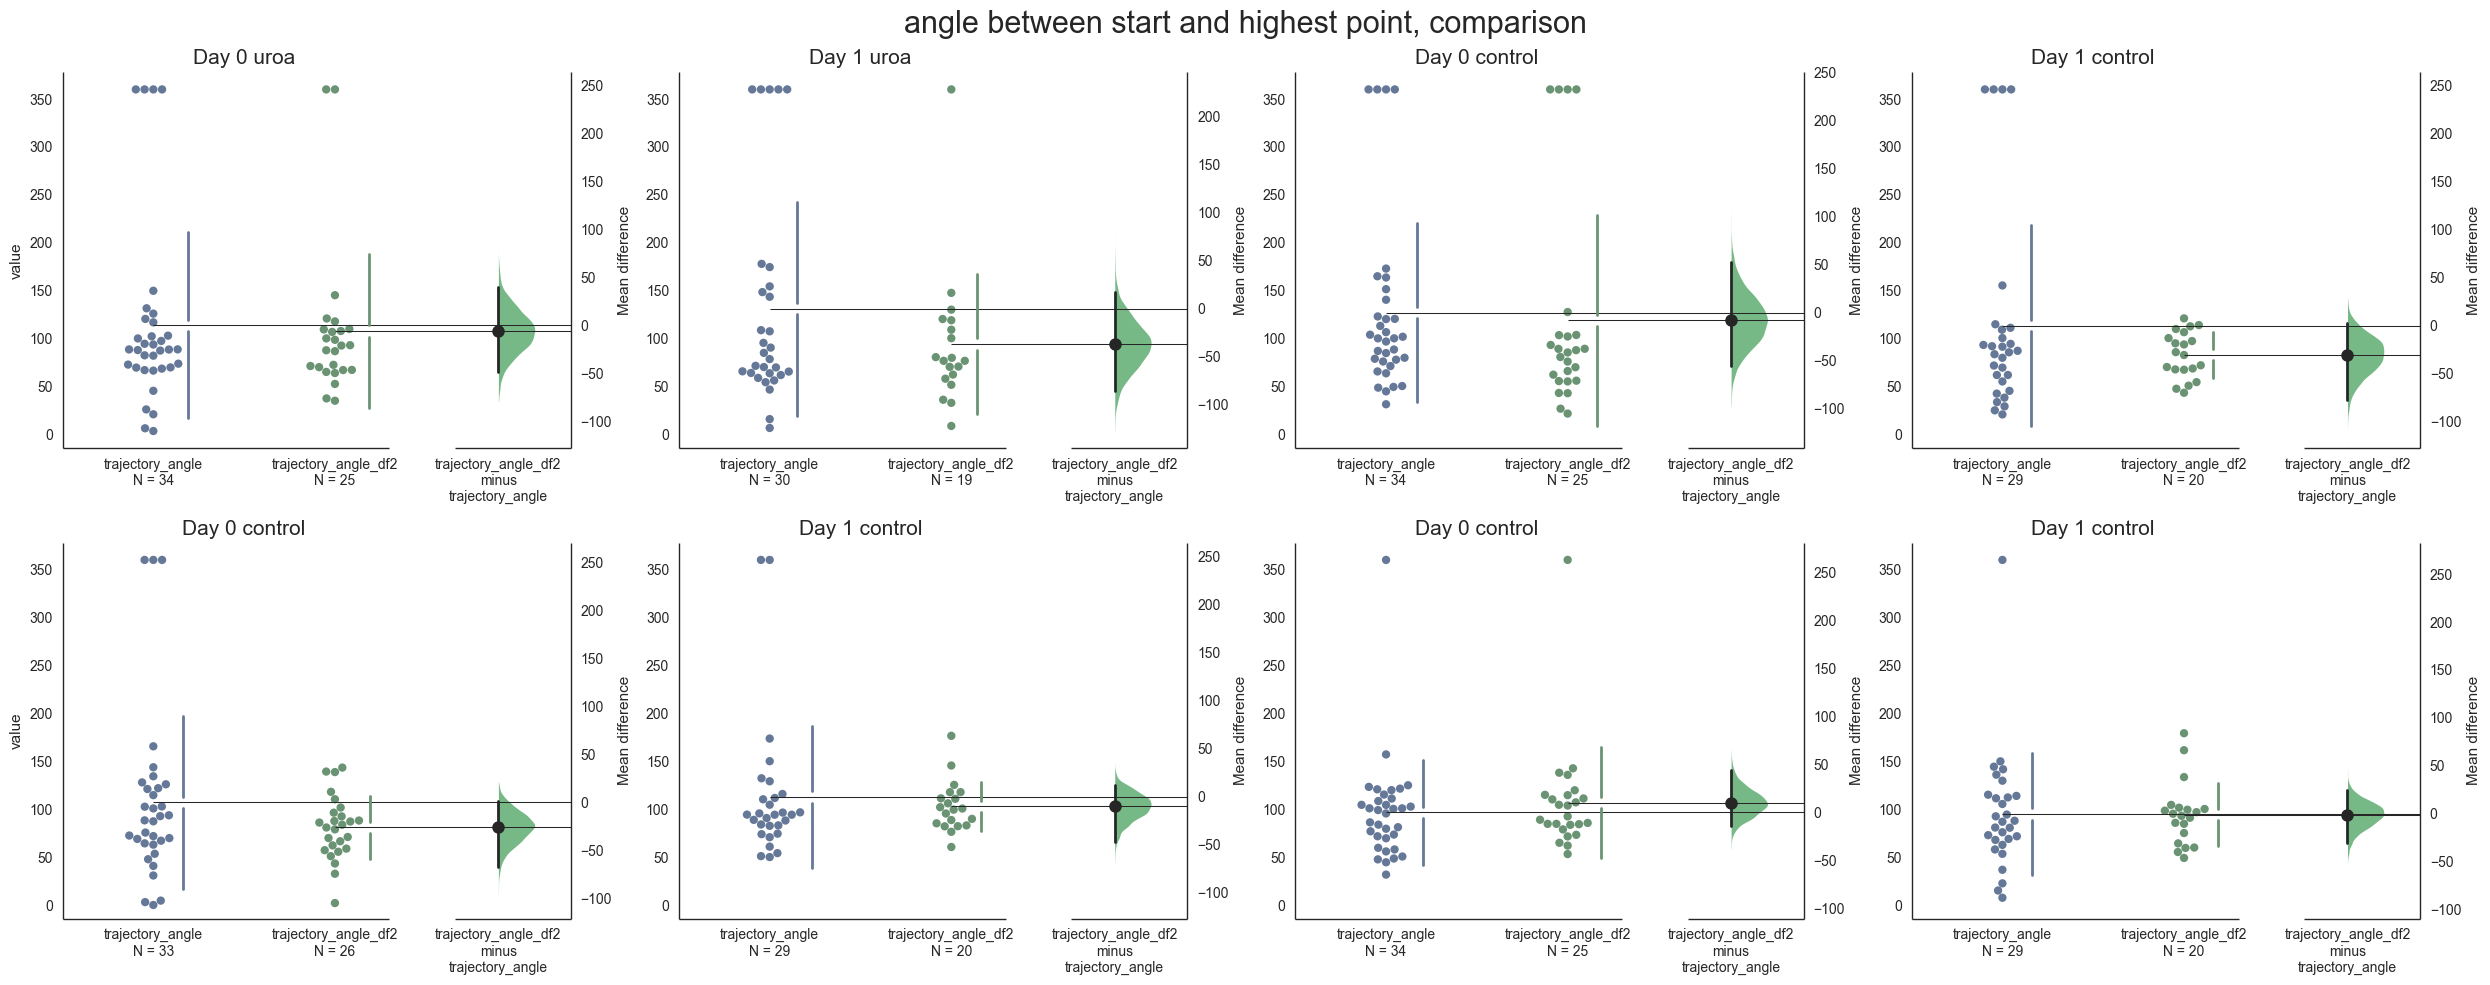

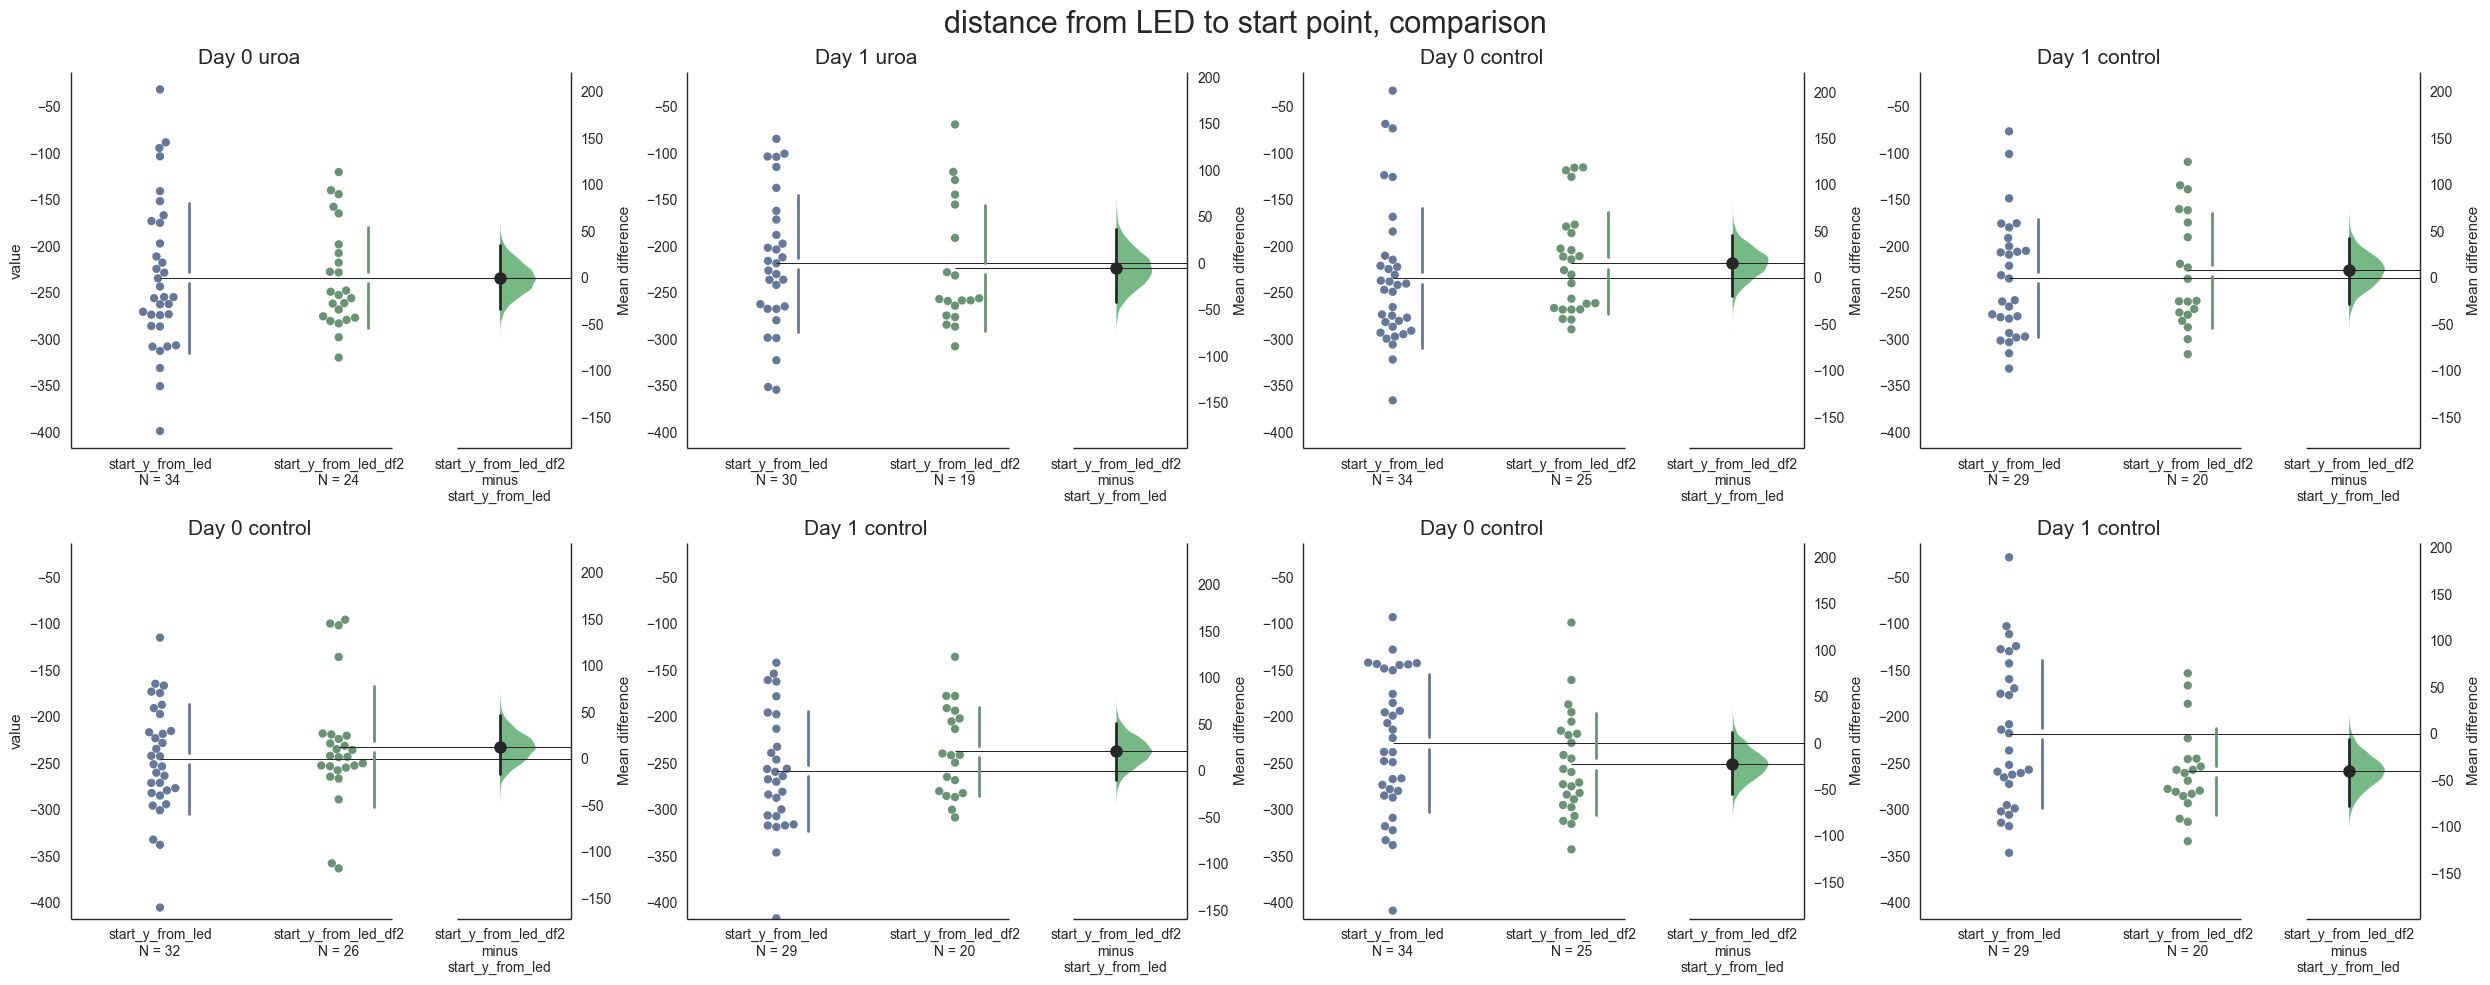

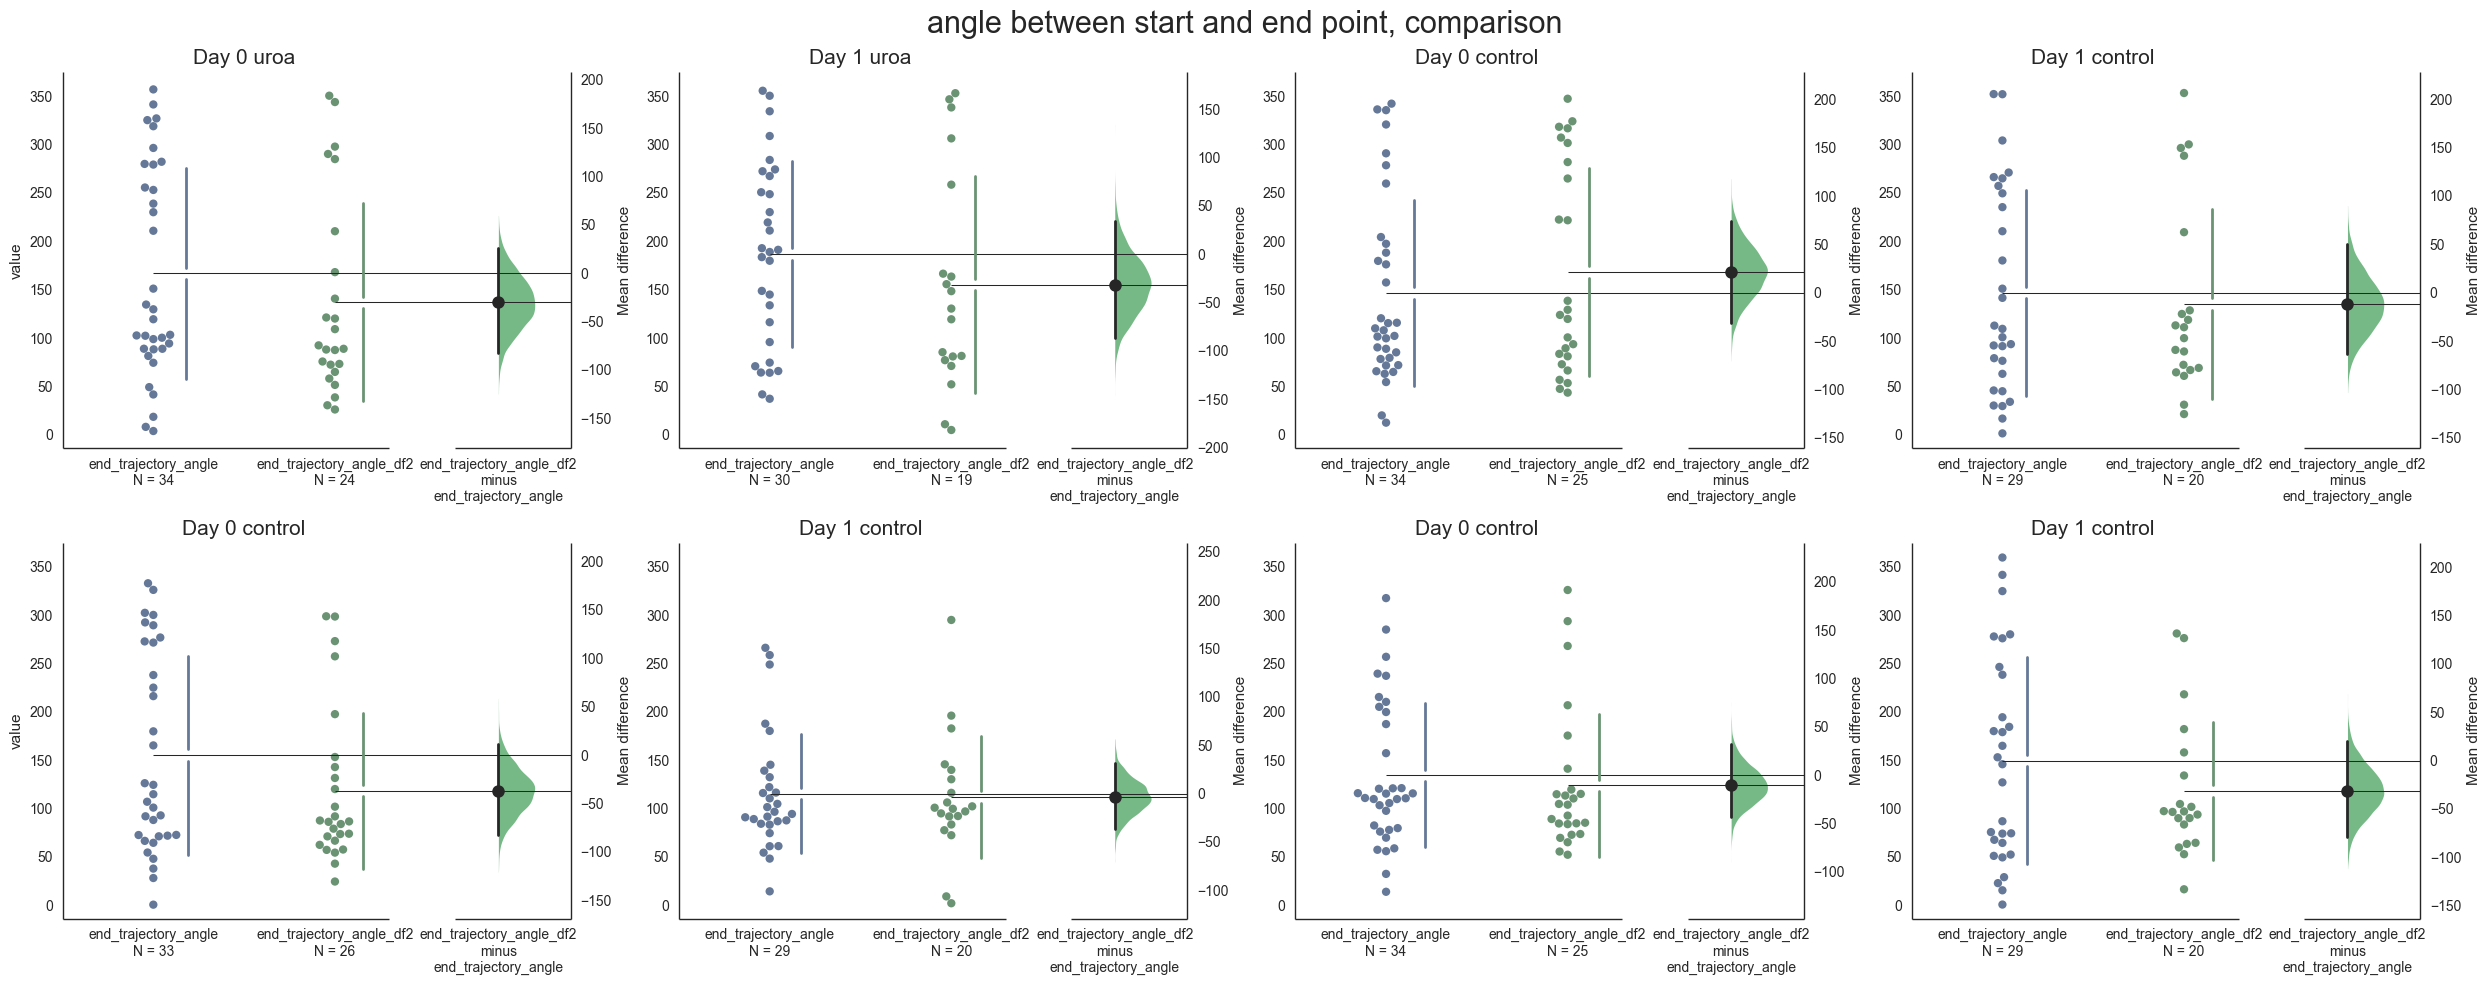

In [7]:
import dabest
os.makedirs(save_path, exist_ok=True)
for parameter in parameters:
    param_save_path = save_path/Path(parameter)
    os.makedirs(param_save_path, exist_ok=True)
    # initialize the figure
    fig, axes = plt.subplots(2, 4, figsize=(25,10), sharey=True)
    plt.suptitle(f"{parameter_dict[parameter]}, comparison", fontsize=22)
    fig.subplots_adjust(hspace=0.7) # leave more space between subplots

    # 2. group the dfs
    param_df1 = df1[["name","uroa_control", "day", parameter]].groupby(["day", "uroa_control"])
    param_df2 = df2[["name","uroa_control", "day", parameter]].groupby(["day", "uroa_control"])
    
    # param_df.to_csv(save_path/Path(f"{parameter}_merged.csv"), index=False)
    # param_df = param_df.groupby(["uroa_control", "day"])
    keys = list(param_df1.groups.keys())

    for i, axes in enumerate(axes.flat):
    # # for i in range(len(keys)):
        # get the group for each axes
        param_condition_day_df = param_df1.get_group(keys[i]).reset_index(drop=True)
        param_condition_day_df2 = param_df2.get_group(keys[i]).reset_index(drop=True)
        # print(param_condition_day_df.head())
        # print(param_condition_day_df2.head())
        # print(parameter)

        # add parameter column from df2 to df1
        param_condition_day_df[parameter+"_df2"] = param_condition_day_df2[parameter]
        param_condition_day_df.to_csv(param_save_path/Path(f"{parameter}_{i}_merged.csv"), index=False)
        # 3. create dabest object
        dabest_obj = dabest.load(param_condition_day_df, idx=(f'{parameter}', f'{parameter}_df2'))
        # 4. save dabest tests (CHOOSE TYPE OF DIFFERENCE TEST)
        tests_df = dabest_obj.mean_diff.statistical_tests
        tests_df.to_csv(param_save_path/Path(f"{parameter}_{i}_dabest_tests.csv"), index=False)
        # 5. plot dabest graph
        dabest_obj.mean_diff.plot(ax=axes)
        
        plt.tight_layout()
        # set the title for the plot
        axes.set_title(f"Day {keys[i][1]} {'uroa' if keys[i][0] == 1 else 'control'}", fontsize=15)

    # 6. save graph
    plt.savefig(param_save_path/Path(f"{parameter}_dabest.png"))
    plt.savefig(param_save_path/Path(f"{parameter}_dabest.svg"))
    plt.show()
    plt.close()
    


In [ ]:
import dabest
os.makedirs(save_path, exist_ok=True)
for parameter in parameters:
    # initialize the figure
    fig, axes = plt.subplots(2, 4, figsize=(25,10), sharey=True)
    plt.suptitle(f"{parameter_dict[parameter]}, comparison", fontsize=22)
    fig.subplots_adjust(hspace=0.7) # leave more space between subplots

    # 2. merge the dfs

    # uroa_control | day | {parameter}_df1 | {parameter}_df2
    # param_df1 = pd.merge(df1[["name","uroa_control", "day", parameter]], , on=["day", "uroa_control"], suffixes=("_df1", "_df2"), how="right")
    param_df1 = df1[["name","uroa_control", "day", parameter]].groupby(["day", "uroa_control"])
    param_df2 = df2[["name","uroa_control", "day", parameter]].groupby(["day", "uroa_control"])
    
    # param_df.to_csv(save_path/Path(f"{parameter}_merged.csv"), index=False)
    # param_df = param_df.groupby(["uroa_control", "day"])
    keys = list(param_df1.groups.keys())

    for i, axes in enumerate(axes.flat):
    # # for i in range(len(keys)):
        # get the group for each axes
        param_condition_day_df1 = param_df1.get_group(keys[i]).reset_index(drop=True)
        param_condition_day_df2 = param_df2.get_group(keys[i]).reset_index(drop=True)
        # print(param_condition_day_df.head())
        # print(param_condition_day_df2.head())
        # print(parameter)
        param_condition_day_df = param_condition_day_df1.merge(param_condition_day_df2, on=["name", "day", "uroa_control"], suffixes=("_df1", "_df2"))

        # add parameter column from df2 to df1
        param_condition_day_df[parameter+"_df2"] = param_condition_day_df2[parameter]
        print(param_condition_day_df.head())

        # 3. create dabest object
        dabest_obj = dabest.load(param_condition_day_df, idx=(f'{parameter}', f'{parameter}_df2'))
        # 4. save dabest tests (CHOOSE TYPE OF DIFFERENCE TEST)
        tests_df = dabest_obj.mean_diff.statistical_tests
        tests_df.to_csv(save_path/Path(f"{parameter}_dabest_tests.csv"), index=False)
        # 5. plot dabest graph
        dabest_obj.mean_diff.plot(ax=axes)
        
        plt.tight_layout()
        # set the title for the plot
        axes.set_title(f"Day {keys[i][1]} {'uroa' if keys[i][0] == 1 else 'control'}", fontsize=15)

    # 6. save graph
    plt.savefig(save_path/Path(f"{parameter}_dabest.png"))
    plt.savefig(save_path/Path(f"{parameter}_dabest.svg"))
    plt.show()
    plt.close()
    
